In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [1]:
import pandas as pd
import wandb
from tqdm import tqdm

api = wandb.Api(timeout=120)

runs = api.runs("lab_frohlich/DeepMechanisticModels.v47.dream_cytof")

all_rows = []
for run in tqdm(runs):
    context = run.config.get("context")
    samples = run.config.get("samples")
    n_hidden = run.config.get("n_hidden")
    depth = run.config.get("depth")
    features = run.config.get("features")
    features_selection = run.config.get("features_selection")
    job = run.config.get("job")
    l1reg_inflater_output = run.config.get("l1reg_inflater_output")
    inflater_output_reg_epoch = run.config.get("inflater_output_reg_epoch")
    l2reg_inflater_output = run.config.get("l2reg_inflater_output")
    sparse_threshold_perc = run.config.get("sparse_threshold_perc")

    try:
        history = run.scan_history(
            keys=["rmse_train", "rmse_val", "_step"],
        )
    except Exception as e:
        print(f"Skipping run {run.id} due to error: {e}")
        continue

    for row in history:
        if row.get("rmse_train") is not None and row.get("rmse_val") is not None:
            all_rows.append({
                # Config
                "context": context,
                "samples": samples,
                "n_hidden": n_hidden,
                "depth": depth,
                "features": features,
                "features_selection": features_selection,
                "job": job,
                "l1reg_inflater_output": l1reg_inflater_output,
                "inflater_output_reg_epoch": inflater_output_reg_epoch,
                "l2reg_inflater_output": l2reg_inflater_output,
                "sparse_threshold_perc": sparse_threshold_perc,
                # Epoch
                "step": row["_step"],
                # RMSEs
                "rmse_train": row["rmse_train"],
                "rmse_val": row["rmse_val"],
            })

results_df = pd.DataFrame(all_rows)
results_df.to_csv("results_feature_selection_v47.csv", index=False)

 29%|██▉       | 1868/6412 [22:01<23:24:27, 18.54s/it]

Skipping run of64bmbd due to error: HTTP 502: 
<html><head>
<meta http-equiv="content-type" content="text/html;charset=utf-8">
<title>502 Server Error</title>
</head>
<body text=#000000 bgcolor=#ffffff>
<h1>Error: Server Error</h1>
<h2>The server encountered a temporary error and could not complete your request.<p>Please try again in 30 seconds.</h2>
<h2></h2>
</body></html>



 87%|████████▋ | 5580/6412 [1:37:59<34:41:38, 150.12s/it]

Skipping run lzihabpi due to error: HTTPSConnectionPool(host='api.wandb.ai', port=443): Read timed out. (read timeout=120)


100%|██████████| 6412/6412 [1:49:01<00:00,  1.02s/it]    


In [2]:
df = pd.read_csv("results_feature_selection_v47.csv")
results_df.head()

,context,samples,n_hidden,depth,features,features_selection,job,l1reg_inflater_output,inflater_output_reg_epoch,l2reg_inflater_output,sparse_threshold_perc,step,rmse_train,rmse_val
0,cytof_init,4of5,2,0,RFE_28_permute,None,3,62.5,100,0,gmm,0,2.680673,3.200103
1,cytof_init,4of5,2,0,RFE_28_permute,None,3,62.5,100,0,gmm,20,1.291063,1.420478
2,cytof_init,4of5,2,0,RFE_28_permute,None,3,62.5,100,0,gmm,40,0.95477,1.000673
3,cytof_init,4of5,2,0,RFE_28_permute,None,3,62.5,100,0,gmm,60,0.788439,0.829219
4,cytof_init,4of5,2,0,RFE_28_permute,None,3,62.5,100,0,gmm,80,0.706763,0.792623


In [3]:
order = df[df['step']==499][['features', 'rmse_val']].groupby(['features']).aggregate(
    {'rmse_val': 'mean'}).sort_values('rmse_val').index.tolist()
order

[]

In [4]:
order_tx = {
    c: df.loc[(df['step']==499) & (df['context'] == c),['features', 'rmse_val']].groupby(['features']).aggregate(
    {'rmse_val': 'mean'}).sort_values('rmse_val').index.tolist()
    for c in ['transcriptomics', 'proteomics']
}
order_tx

{'transcriptomics': [], 'proteomics': []}

In [8]:
df

,context,samples,n_hidden,depth,features,features_selection,job,l1reg_inflater_output,inflater_output_reg_epoch,l2reg_inflater_output,sparse_threshold_perc,step,rmse_train,rmse_val
0,cytof_init,4of5,2,0,RFE_28_permute,NaN,3,62.5,100,0,gmm,0,2.680673,3.200103
1,cytof_init,4of5,2,0,RFE_28_permute,NaN,3,62.5,100,0,gmm,20,1.291063,1.420478
2,cytof_init,4of5,2,0,RFE_28_permute,NaN,3,62.5,100,0,gmm,40,0.954770,1.000673
3,cytof_init,4of5,2,0,RFE_28_permute,NaN,3,62.5,100,0,gmm,60,0.788439,0.829219
4,cytof_init,4of5,2,0,RFE_28_permute,NaN,3,62.5,100,0,gmm,80,0.706763,0.792623
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151061,transcriptomics,0of5,2,0,HVGRFE_4_permute,NaN,3,100.0,100,0,gmm,420,0.698098,0.777858
151062,transcriptomics,0of5,2,0,HVGRFE_4_permute,NaN,3,100.0,100,0,gmm,440,0.669293,0.748634
151063,transcriptomics,0of5,2,0,HVGRFE_4_permute,NaN,3,100.0,100,0,gmm,460,0.645307,0.742318
151064,transcriptomics,0of5,2,0,HVGRFE_4_permute,NaN,3,100.0,100,0,gmm,480,0.625294,0.737569


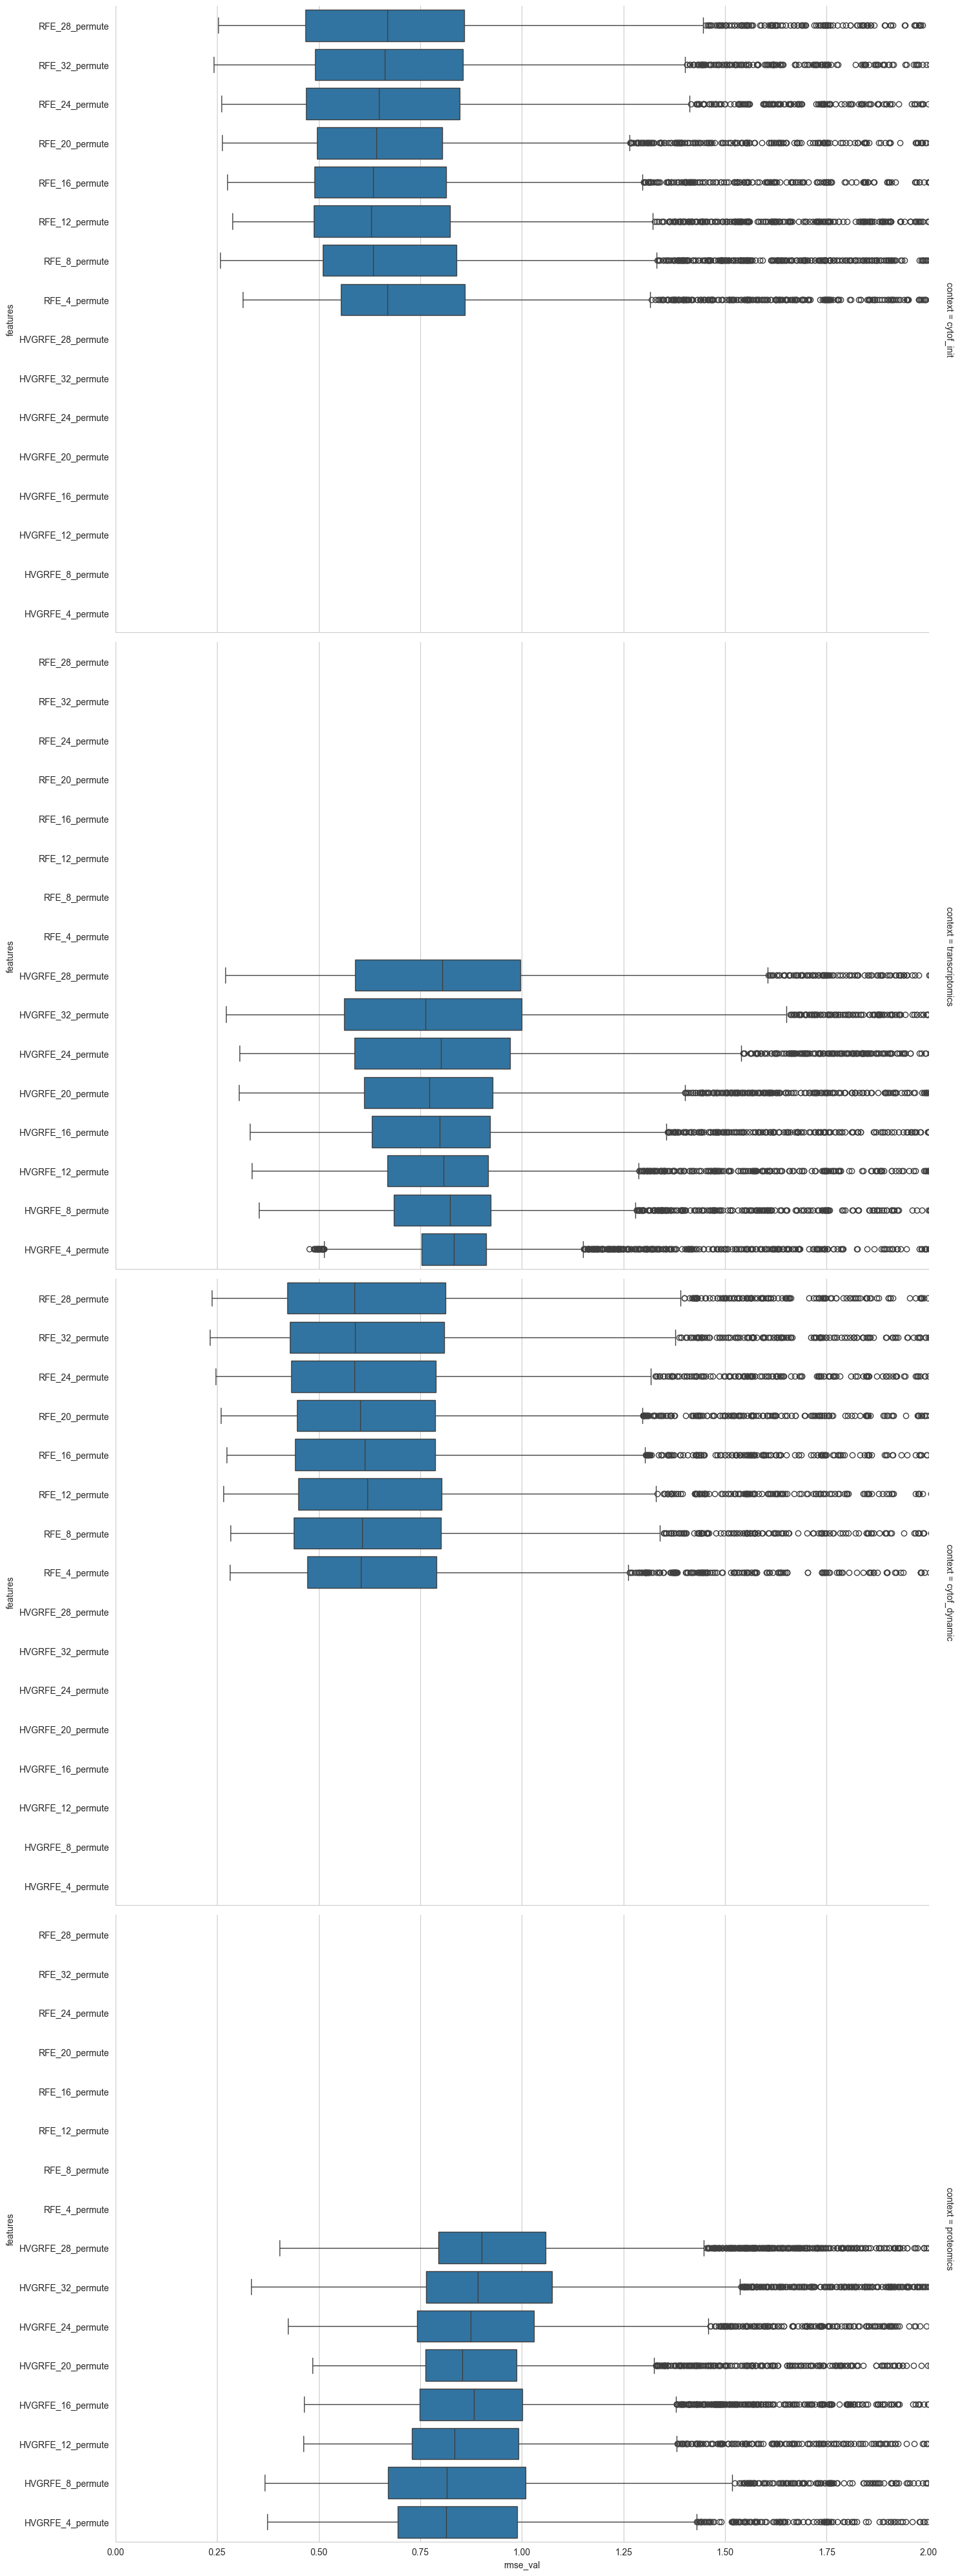

In [12]:
g = sns.FacetGrid(
    df,
    row='context',
    margin_titles=True,
    sharey=True,
    sharex=True,
    height=10,
    aspect=1.5
)
g.map_dataframe(
    sns.boxplot,
    y='features',
    x='rmse_val',
    # order=order,
)
for ax in g.axes.flat:
    ax.set_xlim(0, 2)
plt.show()

/Users/frohlif/Documents/projects/DeepMechanisticModels/venv/lib/python3.13/site-packages/numpy/_core/function_base.py:162: RuntimeWarning: invalid value encountered in multiply
  y *= step
/Users/frohlif/Documents/projects/DeepMechanisticModels/venv/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/Users/frohlif/Documents/projects/DeepMechanisticModels/venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:4671: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
/Users/frohlif/Documents/projects/DeepMechanisticModels/venv/lib/python3.13/site-packages/seaborn/regression.py:242: RuntimeWarning: invalid value encountered in dot
  return np.linalg.pinv(_x).dot(_y)


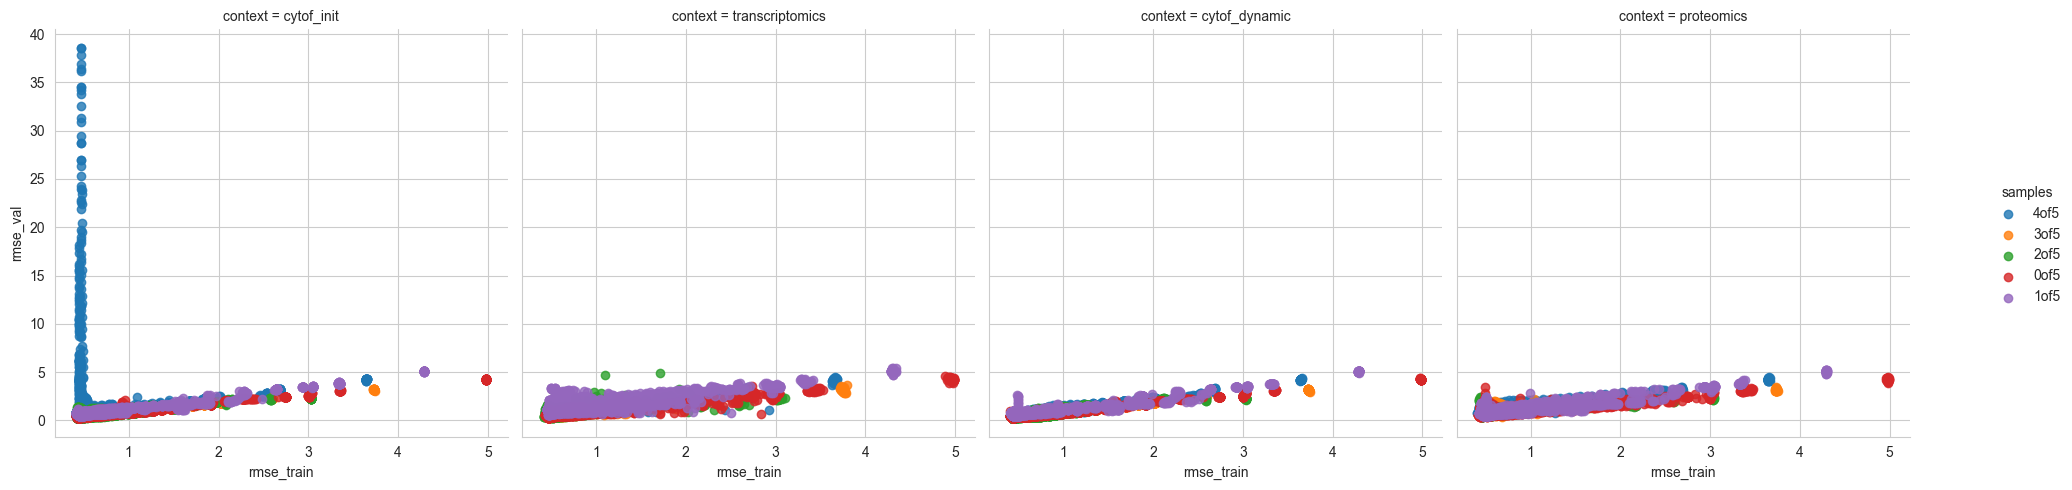

In [13]:
sns.lmplot(
    data=df,
    x='rmse_train',
    y='rmse_val',
    hue='samples',
    col='context',
    height=5,
    aspect=1,
    facet_kws={'margin_titles': True, 'sharey': True, 'sharex': True},
)

In [19]:
sns.lmplot(
    data=df[(df['rmse_val'] < 2.0) & (df['step'] == 499)],
    x='rmse_train',
    y='rmse_val',
    hue='samples',
    col='context',
    height=5,
    aspect=1,
    facet_kws={'margin_titles': True, 'sharey': True, 'sharex': True},
)

ValueError: Number of columns must be a positive integer, not 0

<Figure size 0x500 with 0 Axes>

In [20]:
df[(df['rmse_val'] < 2.0) & (df['step'] == 499)]

,context,samples,n_hidden,depth,features,features_selection,job,l1reg_inflater_output,inflater_output_reg_epoch,l2reg_inflater_output,sparse_threshold_perc,step,rmse_train,rmse_val


In [44]:
df_sub = df[df.features.str.startswith(('HVG', 'RFE')) & (df.step == df.step.max())].copy()
df_sub

,context,samples,n_hidden,depth,features,features_selection,job,l1reg_inflater_output,inflater_output_reg_epoch,l2reg_inflater_output,sparse_threshold_perc,step,rmse_train,rmse_val
11,proteomics,1of5,2,0,HVGRFE_15_tree,NaN,0,100,100,0,gmm,499,0.396865,0.623437
23,proteomics,4of5,2,0,HVGRFE_10_permute,NaN,0,100,100,0,gmm,499,0.393569,0.764516
47,proteomics,0of5,2,0,RFE_15_tree,NaN,3,100,100,0,gmm,499,0.393400,0.605071
71,transcriptomics,1of5,2,0,HVGRFE_15_tree,NaN,1,100,100,0,gmm,499,0.416135,0.656202
95,proteomics,0of5,2,0,HVGRFE_5_permute,NaN,2,100,100,0,gmm,499,0.439829,0.586309
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33251,transcriptomics,3of5,2,0,RFE_15_permute,NaN,3,100,100,0,gmm,499,0.430854,0.722231
33263,transcriptomics,3of5,2,0,RFE_15_permute,NaN,4,100,100,0,gmm,499,0.435548,0.954440
33275,transcriptomics,3of5,2,0,RFE_15_permute,NaN,1,100,100,0,gmm,499,0.425740,1.129433
33287,transcriptomics,3of5,2,0,RFE_15_permute,NaN,0,100,100,0,gmm,499,0.440904,0.899678


In [49]:
df_sub['n_features'] = df_sub['features'].apply(lambda x: int(x.split('_')[1]))
df_sub['method'] = df_sub['features'].apply(lambda x: x.split('_')[0] + '_' + x.split('_')[2])

/Users/frohlif/Documents/projects/DeepMechanisticModels/venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/frohlif/Documents/projects/DeepMechanisticModels/venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/frohlif/Documents/projects/DeepMechanisticModels/venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/frohlif/Documents/projects/DeepMechanisticModels/venv/

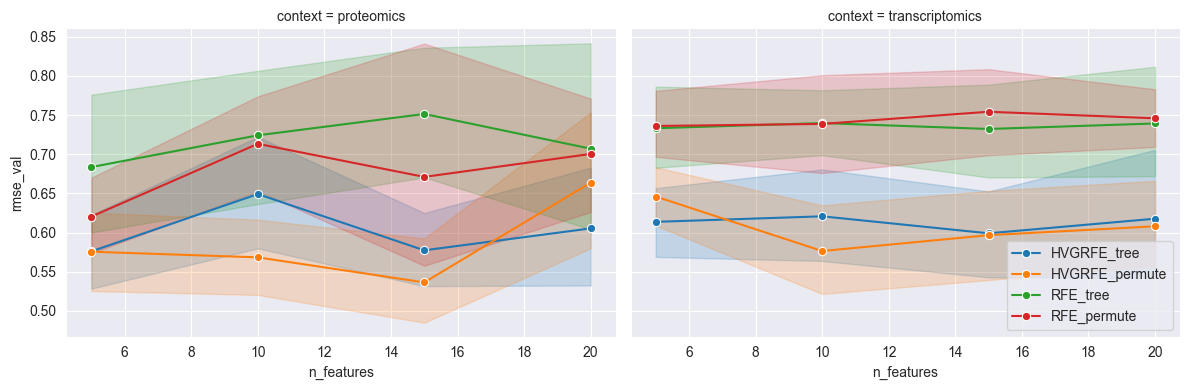

In [50]:
g = sns.FacetGrid(
    df_sub,
    col="context",
    hue="method",
    height=4,
    aspect=1.5
)
g.map_dataframe(
    sns.lineplot,
    x="n_features",
    y="rmse_val",
    marker="o",
    dashes=False
)
plt.legend()

In [54]:
import numpy as np
df_sub

,context,samples,n_hidden,depth,features,features_selection,job,l1reg_inflater_output,inflater_output_reg_epoch,l2reg_inflater_output,sparse_threshold_perc,step,rmse_train,rmse_val,n_features,baseline,method
11,proteomics,1of5,2,0,HVGRFE_15_tree,NaN,0,100,100,0,gmm,499,0.396865,0.623437,15,HVGRFE,HVGRFE_tree
23,proteomics,4of5,2,0,HVGRFE_10_permute,NaN,0,100,100,0,gmm,499,0.393569,0.764516,10,HVGRFE,HVGRFE_permute
47,proteomics,0of5,2,0,RFE_15_tree,NaN,3,100,100,0,gmm,499,0.393400,0.605071,15,RFE,RFE_tree
71,transcriptomics,1of5,2,0,HVGRFE_15_tree,NaN,1,100,100,0,gmm,499,0.416135,0.656202,15,HVGRFE,HVGRFE_tree
95,proteomics,0of5,2,0,HVGRFE_5_permute,NaN,2,100,100,0,gmm,499,0.439829,0.586309,5,HVGRFE,HVGRFE_permute
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33251,transcriptomics,3of5,2,0,RFE_15_permute,NaN,3,100,100,0,gmm,499,0.430854,0.722231,15,RFE,RFE_permute
33263,transcriptomics,3of5,2,0,RFE_15_permute,NaN,4,100,100,0,gmm,499,0.435548,0.954440,15,RFE,RFE_permute
33275,transcriptomics,3of5,2,0,RFE_15_permute,NaN,1,100,100,0,gmm,499,0.425740,1.129433,15,RFE,RFE_permute
33287,transcriptomics,3of5,2,0,RFE_15_permute,NaN,0,100,100,0,gmm,499,0.440904,0.899678,15,RFE,RFE_permute
